In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, KFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

import time

# Настройка стиля графиков
plt.rcParams.update({
    'figure.figsize': (12, 6),
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'font.family': 'DejaVu Sans',
})
sns.set_style('whitegrid')




## 1. Загрузка и первичный осмотр данных

Первым делом загружаем датасет и смотрим на его размер, типы столбцов и наличие пропусков.

In [2]:
df_raw = pd.read_csv('ToyotaCorolla.csv')

print(f"Размер датасета: {df_raw.shape[0]} строк × {df_raw.shape[1]} столбцов")
print("\n--- Первые 5 строк ---")
df_raw.head()


Размер датасета: 1436 строк × 39 столбцов

--- Первые 5 строк ---


,Id,Model,Price,Age_08_04,Mfg_Month,Mfg_Year,KM,Fuel_Type,HP,Met_Color,...,Powered_Windows,Power_Steering,Radio,Mistlamps,Sport_Model,Backseat_Divider,Metallic_Rim,Radio_cassette,Parking_Assistant,Tow_Bar
0,1,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,13500,23,10,2002,46986,Diesel,90,1,...,1,1,0,0,0,1,0,0,0,0
1,2,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,13750,23,10,2002,72937,Diesel,90,1,...,0,1,0,0,0,1,0,0,0,0
2,3,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,13950,24,9,2002,41711,Diesel,90,1,...,0,1,0,0,0,1,0,0,0,0
3,4,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,14950,26,7,2002,48000,Diesel,90,0,...,0,1,0,0,0,1,0,0,0,0
4,5,TOYOTA Corolla 2.0 D4D HATCHB SOL 2/3-Doors,13750,30,3,2002,38500,Diesel,90,0,...,1,1,0,1,0,1,0,0,0,0


In [3]:
# Типы данных и базовая статистика
print("=== Типы данных ===")
print(df_raw.dtypes.value_counts())
print()
print("=== Пропущенные значения ===")
nulls = df_raw.isnull().sum()
print(nulls[nulls > 0] if nulls.any() else "Пропусков нет")


=== Типы данных ===
int64     36
object     3
Name: count, dtype: int64

=== Пропущенные значения ===
Пропусков нет


In [4]:
# Числовые признаки — базовая статистика
df_raw.describe().round(2)


,Id,Price,Age_08_04,Mfg_Month,Mfg_Year,KM,HP,Met_Color,Automatic,CC,...,Powered_Windows,Power_Steering,Radio,Mistlamps,Sport_Model,Backseat_Divider,Metallic_Rim,Radio_cassette,Parking_Assistant,Tow_Bar
count,1436.00,1436.00,1436.00,1436.00,1436.00,1436.00,1436.00,1436.00,1436.00,1436.00,...,1436.00,1436.00,1436.00,1436.00,1436.00,1436.00,1436.0,1436.00,1436.00,1436.00
mean,721.56,10730.82,55.95,5.55,1999.63,68533.26,101.50,0.67,0.06,1576.86,...,0.56,0.98,0.15,0.26,0.30,0.77,0.2,0.15,0.00,0.28
std,416.48,3626.96,18.60,3.35,1.54,37506.45,14.98,0.47,0.23,424.39,...,0.50,0.15,0.35,0.44,0.46,0.42,0.4,0.35,0.05,0.45
min,1.00,4350.00,1.00,1.00,1998.00,1.00,69.00,0.00,0.00,1300.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.0,0.00,0.00,0.00
25%,361.75,8450.00,44.00,3.00,1998.00,43000.00,90.00,0.00,0.00,1400.00,...,0.00,1.00,0.00,0.00,0.00,1.00,0.0,0.00,0.00,0.00
50%,721.50,9900.00,61.00,5.00,1999.00,63389.50,110.00,1.00,0.00,1600.00,...,1.00,1.00,0.00,0.00,0.00,1.00,0.0,0.00,0.00,0.00
75%,1081.25,11950.00,70.00,8.00,2001.00,87020.75,110.00,1.00,0.00,1600.00,...,1.00,1.00,0.00,1.00,1.00,1.00,0.0,0.00,0.00,1.00
max,1442.00,32500.00,80.00,12.00,2004.00,243000.00,192.00,1.00,1.00,16000.00,...,1.00,1.00,1.00,1.00,1.00,1.00,1.0,1.00,1.00,1.00


## 2. Разведочный анализ данных (EDA)

### 2.1 Распределение целевой переменной `Price`

**Зачем смотреть на распределение?** Линейная регрессия предполагает, что остатки распределены нормально. Сильно скошенное распределение целевой переменной - сигнал о том, что стоит рассмотреть логарифмическое преобразование.

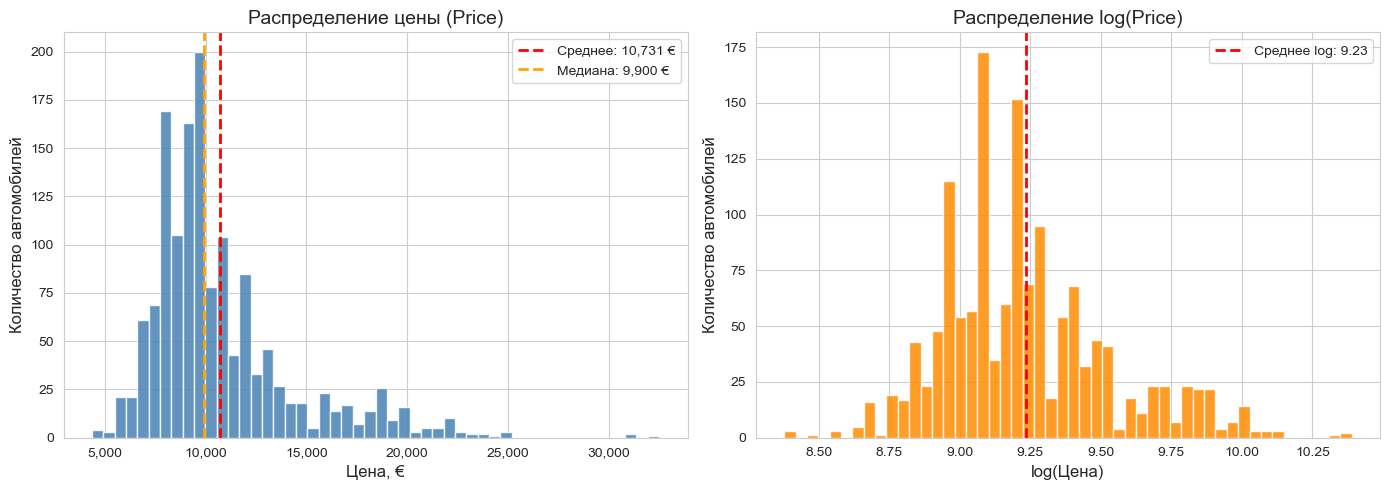

Коэффициент асимметрии (skewness) цены: 1.704
Коэффициент асимметрии log(цены):        0.734

💡 Вывод: распределение цены имеет правостороннюю асимметрию (skew ≈ 1.70),
   что типично для цен. После логарифмирования распределение близко к нормальному.
   Будем предсказывать log(Price), а затем переводить обратно через exp().


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Гистограмма цены
axes[0].hist(df_raw['Price'], bins=50, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(df_raw['Price'].mean(), color='red', linestyle='--', linewidth=2, label=f"Среднее: {df_raw['Price'].mean():,.0f} €")
axes[0].axvline(df_raw['Price'].median(), color='orange', linestyle='--', linewidth=2, label=f"Медиана: {df_raw['Price'].median():,.0f} €")
axes[0].set_title('Распределение цены (Price)')
axes[0].set_xlabel('Цена, €')
axes[0].set_ylabel('Количество автомобилей')
axes[0].legend()
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Логарифм цены
log_price = np.log(df_raw['Price'])
axes[1].hist(log_price, bins=50, color='darkorange', edgecolor='white', alpha=0.85)
axes[1].axvline(log_price.mean(), color='red', linestyle='--', linewidth=2, label=f"Среднее log: {log_price.mean():.2f}")
axes[1].set_title('Распределение log(Price)')
axes[1].set_xlabel('log(Цена)')
axes[1].set_ylabel('Количество автомобилей')
axes[1].legend()

plt.tight_layout()
plt.savefig('price_distribution.png', dpi=120, bbox_inches='tight')
plt.show()

skewness = df_raw['Price'].skew()
print(f"Коэффициент асимметрии (skewness) цены: {skewness:.3f}")
print(f"Коэффициент асимметрии log(цены):        {log_price.skew():.3f}")
print()
print("💡 Вывод: распределение цены имеет правостороннюю асимметрию (skew ≈ {:.2f}),".format(skewness))
print("   что типично для цен. После логарифмирования распределение близко к нормальному.")
print("   Будем предсказывать log(Price), а затем переводить обратно через exp().")


### 2.2 Ключевые числовые признаки и их взаимосвязь с ценой

Смотрим, как цена зависит от основных непрерывных характеристик.

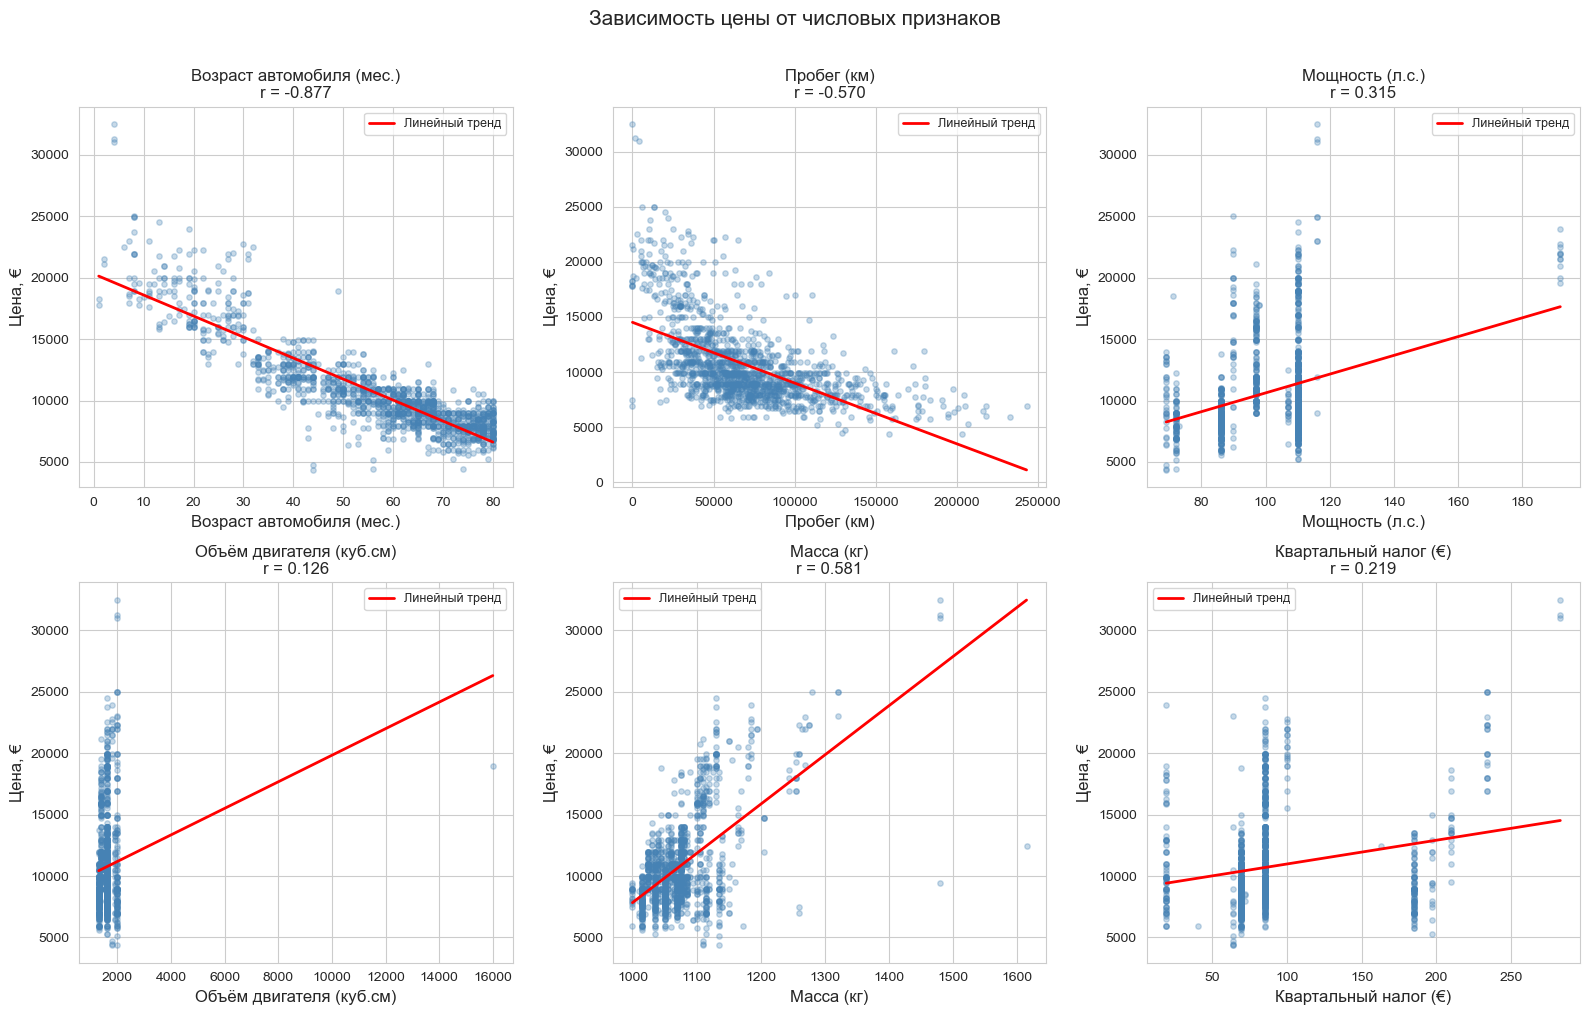

📊 Наблюдения:
  • Age_08_04 (возраст): сильная отрицательная корреляция (r ≈ -0.88) — старше → дешевле
  • KM (пробег): умеренная отрицательная корреляция (r ≈ -0.57) — больше пробег → дешевле
  • HP (мощность): умеренная положительная корреляция (r ≈ +0.36) — мощнее → дороже
  • CC: слабая положительная, но нелинейная (есть выброс 16000 куб.см)
  • Weight: умеренная положительная корреляция


In [6]:
key_numeric = ['Age_08_04', 'KM', 'HP', 'CC', 'Weight', 'Quarterly_Tax']
labels = {
    'Age_08_04':    'Возраст автомобиля (мес.)',
    'KM':           'Пробег (км)',
    'HP':           'Мощность (л.с.)',
    'CC':           'Объём двигателя (куб.см)',
    'Weight':       'Масса (кг)',
    'Quarterly_Tax':'Квартальный налог (€)',
}

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(key_numeric):
    axes[i].scatter(df_raw[col], df_raw['Price'], alpha=0.3, s=15, color='steelblue')
    # Линия тренда
    z = np.polyfit(df_raw[col], df_raw['Price'], 1)
    p = np.poly1d(z)
    xs = np.linspace(df_raw[col].min(), df_raw[col].max(), 200)
    axes[i].plot(xs, p(xs), 'r-', linewidth=2, label='Линейный тренд')
    corr = df_raw[col].corr(df_raw['Price'])
    axes[i].set_title(f'{labels[col]}\nr = {corr:.3f}', fontsize=12)
    axes[i].set_xlabel(labels[col])
    axes[i].set_ylabel('Цена, €')
    axes[i].legend(fontsize=9)

plt.suptitle('Зависимость цены от числовых признаков', fontsize=15, y=1.01)
plt.tight_layout()
plt.savefig('scatter_numeric.png', dpi=120, bbox_inches='tight')
plt.show()
print("📊 Наблюдения:")
print("  • Age_08_04 (возраст): сильная отрицательная корреляция (r ≈ -0.88) — старше → дешевле")
print("  • KM (пробег): умеренная отрицательная корреляция (r ≈ -0.57) — больше пробег → дешевле")  
print("  • HP (мощность): умеренная положительная корреляция (r ≈ +0.36) — мощнее → дороже")
print("  • CC: слабая положительная, но нелинейная (есть выброс 16000 куб.см)")
print("  • Weight: умеренная положительная корреляция")


### 2.3 Категориальные признаки

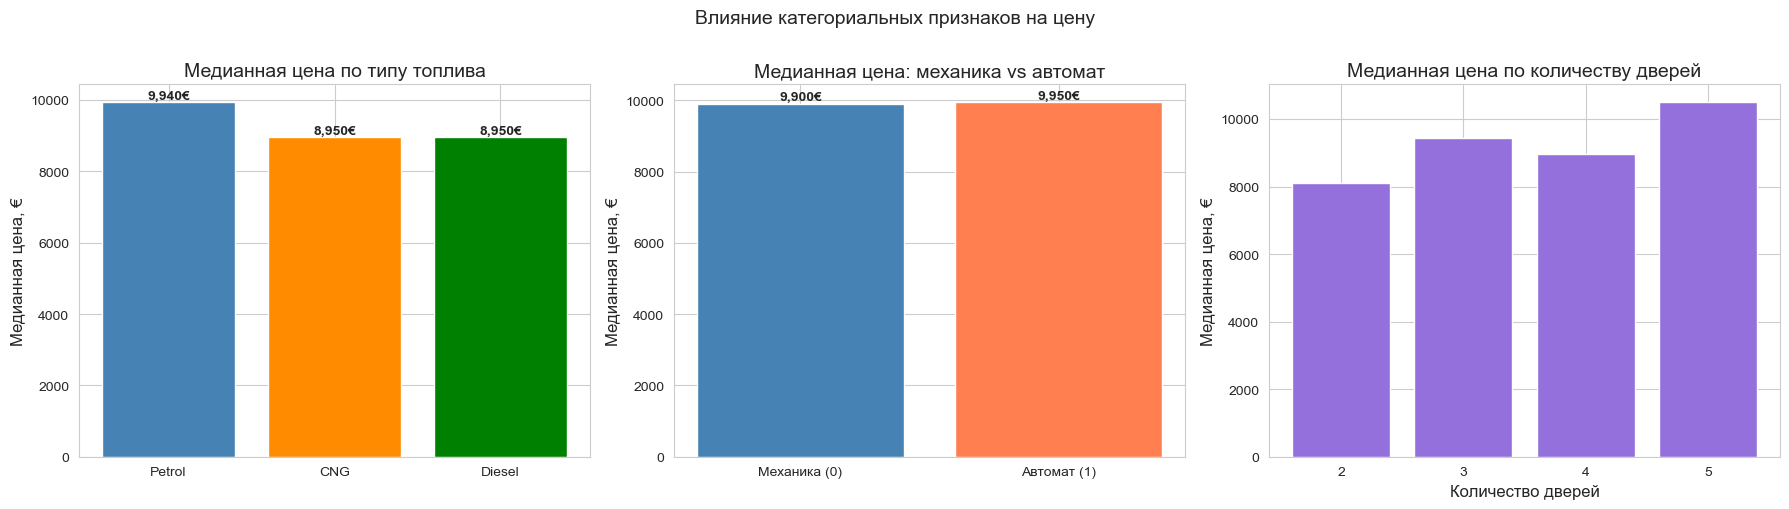

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Fuel_Type
fuel_stats = df_raw.groupby('Fuel_Type')['Price'].median().sort_values(ascending=False)
axes[0].bar(fuel_stats.index, fuel_stats.values, color=['steelblue','darkorange','green'])
axes[0].set_title('Медианная цена по типу топлива')
axes[0].set_ylabel('Медианная цена, €')
for i, (k, v) in enumerate(fuel_stats.items()):
    axes[0].text(i, v + 100, f'{v:,.0f}€', ha='center', fontsize=10, fontweight='bold')

# Automatic
auto_stats = df_raw.groupby('Automatic')['Price'].median()
axes[1].bar(['Механика (0)', 'Автомат (1)'], auto_stats.values, color=['steelblue','coral'])
axes[1].set_title('Медианная цена: механика vs автомат')
axes[1].set_ylabel('Медианная цена, €')
for i, v in enumerate(auto_stats.values):
    axes[1].text(i, v + 100, f'{v:,.0f}€', ha='center', fontsize=10, fontweight='bold')

# Doors
door_stats = df_raw.groupby('Doors')['Price'].median().sort_index()
axes[2].bar([str(d) for d in door_stats.index], door_stats.values, color='mediumpurple')
axes[2].set_title('Медианная цена по количеству дверей')
axes[2].set_xlabel('Количество дверей')
axes[2].set_ylabel('Медианная цена, €')

plt.suptitle('Влияние категориальных признаков на цену', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('categorical_price.png', dpi=120, bbox_inches='tight')
plt.show()


Можно увидеть, что машины на бензине стоят дороже, чем на других видах топлива;
Механика и автомат никак не влияют на распределение цен на авто, что можно сказать и про количество дверей, возможно, большая стоимость за большее количество дверей вызвано большими габаритами машин с большим количетвом дверей, хотя у спорткаров меньше дверей - но и цена намного дороже (НО это не про тоёту точно)

### 2.4 Матрица корреляций

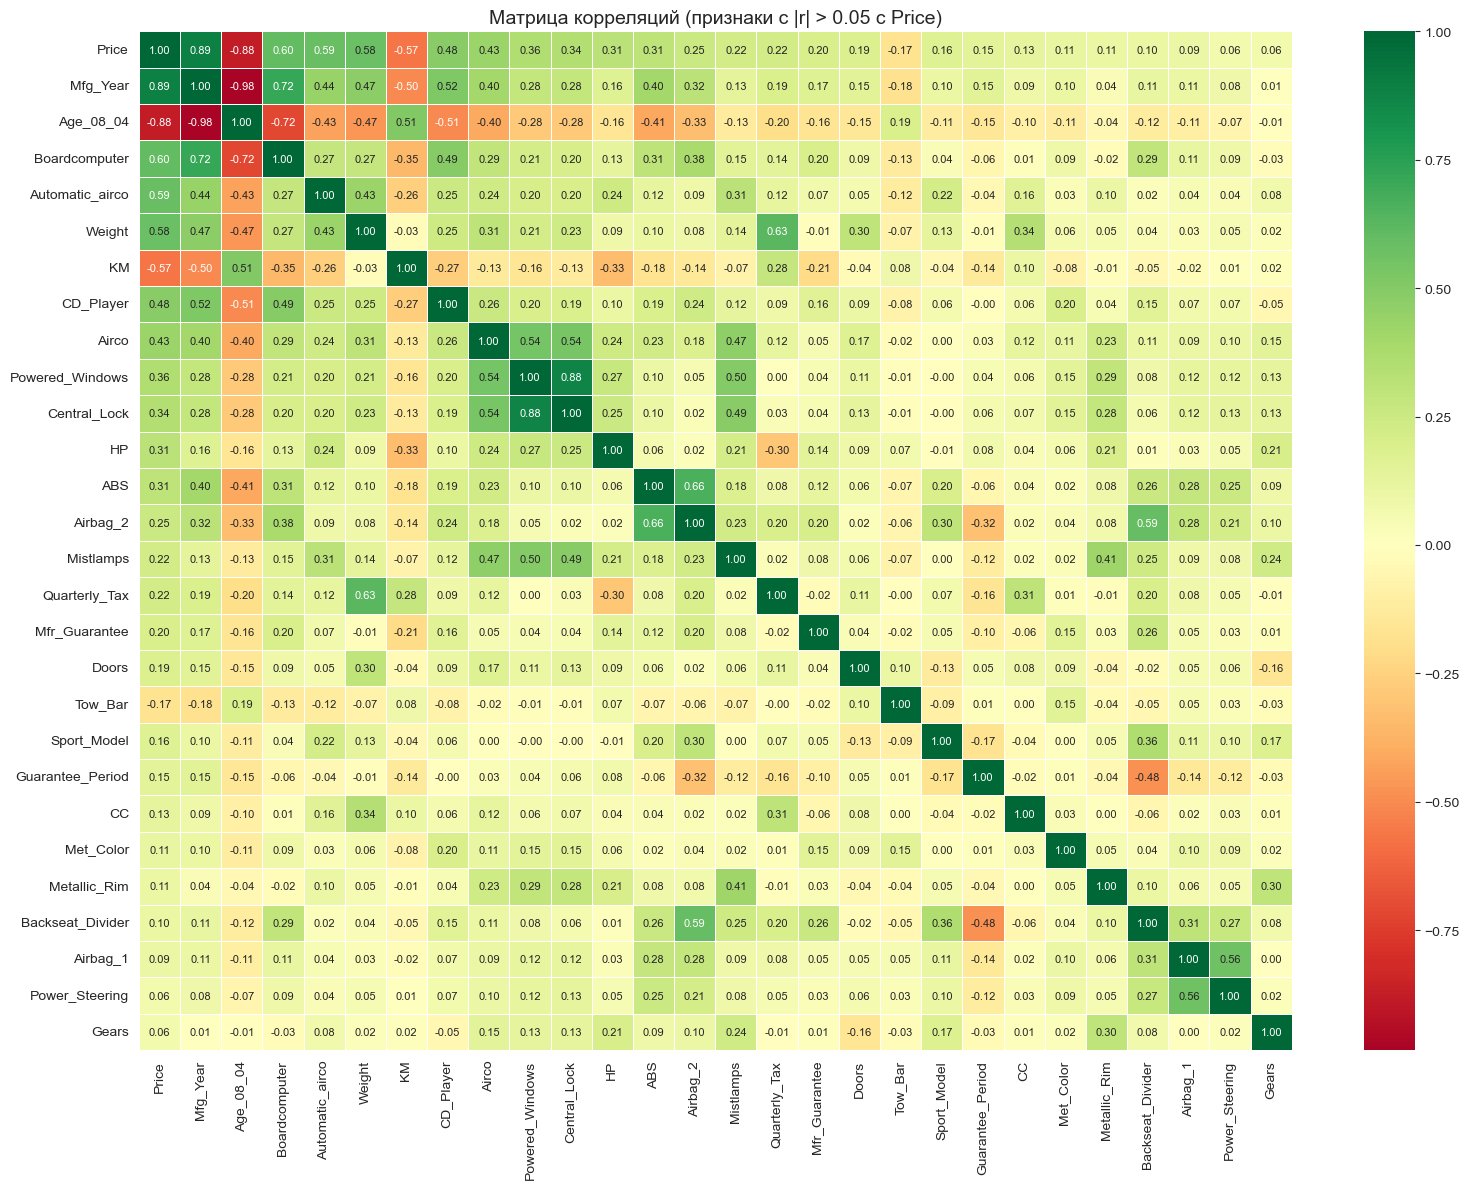

Топ-10 признаков по корреляции с Price:
Mfg_Year           0.885
Age_08_04          0.877
Boardcomputer      0.601
Automatic_airco    0.588
Weight             0.581
KM                 0.570
CD_Player          0.481
Airco              0.429
Powered_Windows    0.357
Central_Lock       0.343


In [8]:
# Выбираем числовые признаки для матрицы корреляций
numeric_cols = df_raw.select_dtypes(include=np.number).columns.tolist()
numeric_cols = [c for c in numeric_cols if c not in ['Id', 'Cylinders']]  # Id — идентификатор

corr_matrix = df_raw[numeric_cols].corr()

# Показываем только признаки с |corr| > 0.1 по отношению к Price
price_corr = corr_matrix['Price'].drop('Price').abs().sort_values(ascending=False)
top_features = price_corr[price_corr > 0.05].index.tolist()

fig, ax = plt.subplots(figsize=(16, 12))
mask = np.triu(np.ones_like(corr_matrix.loc[['Price'] + top_features, ['Price'] + top_features], dtype=bool))
sns.heatmap(
    corr_matrix.loc[['Price'] + top_features, ['Price'] + top_features],
    annot=True, fmt='.2f', cmap='RdYlGn', center=0,
    linewidths=0.5, ax=ax,
    annot_kws={'size': 8}
)
ax.set_title('Матрица корреляций (признаки с |r| > 0.05 с Price)', fontsize=14)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()

print("Топ-10 признаков по корреляции с Price:")
print(price_corr.head(10).round(3).to_string())


**Что мы поняли, проведя EDA:**

1. **Пропусков нет** — данные чистые, предобработка будет несложной.
2. **Цена имеет правостороннюю асимметрию** — логарифмическое преобразование улучшит качество модели.
3. **Возраст (`Age_08_04`) и пробег (`KM`)** — наиболее мощные предикторы цены (|r| > 0.5).
4. **Выброс в `CC`** — значение 16000 куб.см явно является опечаткой (нет таких двигателей у Corolla).
5. **`Cylinders`** — константный признак (везде 4), его нужно удалить.
6. **`Mfg_Month` и `Mfg_Year`** несут ту же информацию, что и `Age_08_04` — можно убрать мультиколлинеарность.
7. **Много бинарных признаков** (опции) — они дают суммарный аддитивный эффект на цену.


## 3. Предобработка данных

### 3.1 Как мы предобрабатывали данные

**Шаги предобработки:**
1. Удаление бессмысленных столбцов (`Id`, `Cylinders` как константа).
2. Исправление выброса в `CC` (значение 16000 → медиана).
3. Логарифмическое преобразование целевой переменной `Price`.
4. Кодирование категориальных переменных (`Fuel_Type`, `Color`) через One-Hot Encoding.
5. Масштабирование числовых признаков (StandardScaler) перед обучением.


In [9]:
df = df_raw.copy()

# --- Шаг 1: Удаляем столбцы-"мусор" ---
# Id — это просто порядковый номер строки, не несёт смысловой нагрузки
# Cylinders — все 1436 значений равны 4 (нет изменчивости → признак бесполезен для модели)
# Model - слишком много уникальных категорий (>50), большинство встречается редко; информация
#          уже покрыта другими признаками (HP, CC, Doors, Age и т.д.)
# Mfg_Month, Mfg_Year - дата производства фактически уже закодирована в Age_08_04
#   (Age = апрель 2004 - дата выпуска). Оставляем Age, удаляем избыточные.
cols_to_drop = ['Id', 'Cylinders', 'Model', 'Mfg_Month', 'Mfg_Year']
df.drop(columns=cols_to_drop, inplace=True)
print(f"Удалено {len(cols_to_drop)} столбцов: {cols_to_drop}")

# --- Шаг 2: Исправляем выброс в CC ---
# Значение 16000 куб.см - явная опечатка (у Corolla двигатели 1.3–2.0л)
# Заменяем на медиану колонки, посчитанную без выброса
cc_without_outlier = df.loc[df['CC'] < 10000, 'CC'].median()
outlier_count = (df['CC'] >= 10000).sum()
df.loc[df['CC'] >= 10000, 'CC'] = cc_without_outlier
print(f"Исправлено {outlier_count} значений CC (16000 → {cc_without_outlier:.0f})")

# --- Шаг 3: Логарифмическое преобразование Price ---
# Делаем это до разбивки, чтобы всюду работать с log(Price)
df['logPrice'] = np.log(df['Price'])
print(f"\nЛогарифмирована целевая переменная → 'logPrice'")
print(f"  Price     range: [{df['Price'].min()}, {df['Price'].max()}]")
print(f"  logPrice  range: [{df['logPrice'].min():.3f}, {df['logPrice'].max():.3f}]")

print(f"\nИтоговый датасет: {df.shape[0]} строк × {df.shape[1]} столбцов")


Удалено 5 столбцов: ['Id', 'Cylinders', 'Model', 'Mfg_Month', 'Mfg_Year']
Исправлено 1 значений CC (16000 → 1600)

Логарифмирована целевая переменная → 'logPrice'
  Price     range: [4350, 32500]
  logPrice  range: [8.378, 10.389]

Итоговый датасет: 1436 строк × 35 столбцов


## 4.(Feature Engineering)

Линейные модели не умеют сами обнаруживать нелинейности и взаимодействия. Поэтому мы вручную создаём новые признаки.

**Как мы работаем с признаками:**
- Добавим нелинейные преобразования (`Age²`, `log(KM+1)`) - чтобы линейная модель могла аппроксимировать нелинейные зависимости.
- Добавим взаимодействие `Age × KM` — пожилой автомобиль с большим пробегом теряет в цене быстрее.
- Добавим агрегированный признак `Options_Count` — суммарное количество опций.


In [10]:
# --- Признаки, которые были добавлены ---

# 1. Age_squared: квадрат возраста
#    Зависимость цены от возраста нелинейна (сначала резкое падение, затем плато)
df['Age_squared'] = df['Age_08_04'] ** 2

# 2. log_KM: логарифм пробега
#    Пробег тоже нелинейно влияет на цену: первые 50 000 км "стоят дороже", чем следующие
df['log_KM'] = np.log1p(df['KM'])  # log1p = log(1 + x), безопасно для 0

# 3. Age_KM_interaction: взаимодействие возраста и пробега
#    Старый автомобиль с большим пробегом теряет в цене сильнее, чем можно предсказать
#    только по каждому из признаков по отдельности
df['Age_KM_interaction'] = df['Age_08_04'] * df['log_KM']

# 4. Power_to_Weight: мощность на единицу массы (удельная мощность)
#    Характеризует "спортивность" — более спортивные авто ценятся дороже
df['Power_to_Weight'] = df['HP'] / df['Weight']

# 5. Options_Count: суммарное количество опций
#    Более "навороченный" автомобиль стоит дороже
option_cols = [
    'ABS', 'Airbag_1', 'Airbag_2', 'Airco', 'Automatic_airco', 'Boardcomputer',
    'CD_Player', 'Central_Lock', 'Powered_Windows', 'Power_Steering', 'Radio',
    'Mistlamps', 'Sport_Model', 'Backseat_Divider', 'Metallic_Rim',
    'Radio_cassette', 'Parking_Assistant', 'Tow_Bar'
]
df['Options_Count'] = df[option_cols].sum(axis=1)

new_features = ['Age_squared', 'log_KM', 'Age_KM_interaction', 'Power_to_Weight', 'Options_Count']
print("Добавлено новых признаков:", new_features)
print()

# Проверяем корреляцию новых признаков с logPrice
print("Корреляция с logPrice:")
print("-" * 40)
for f in new_features + ['Age_08_04', 'KM', 'HP']:
    r = df[f].corr(df['logPrice'])
    print(f"  {f:30s}: {r:+.4f}")


Добавлено новых признаков: ['Age_squared', 'log_KM', 'Age_KM_interaction', 'Power_to_Weight', 'Options_Count']

Корреляция с logPrice:
----------------------------------------
  Age_squared                   : -0.8387
  log_KM                        : -0.5081
  Age_KM_interaction            : -0.8792
  Power_to_Weight               : +0.1505
  Options_Count                 : +0.5626
  Age_08_04                     : -0.8767
  KM                            : -0.6090
  HP                            : +0.3160


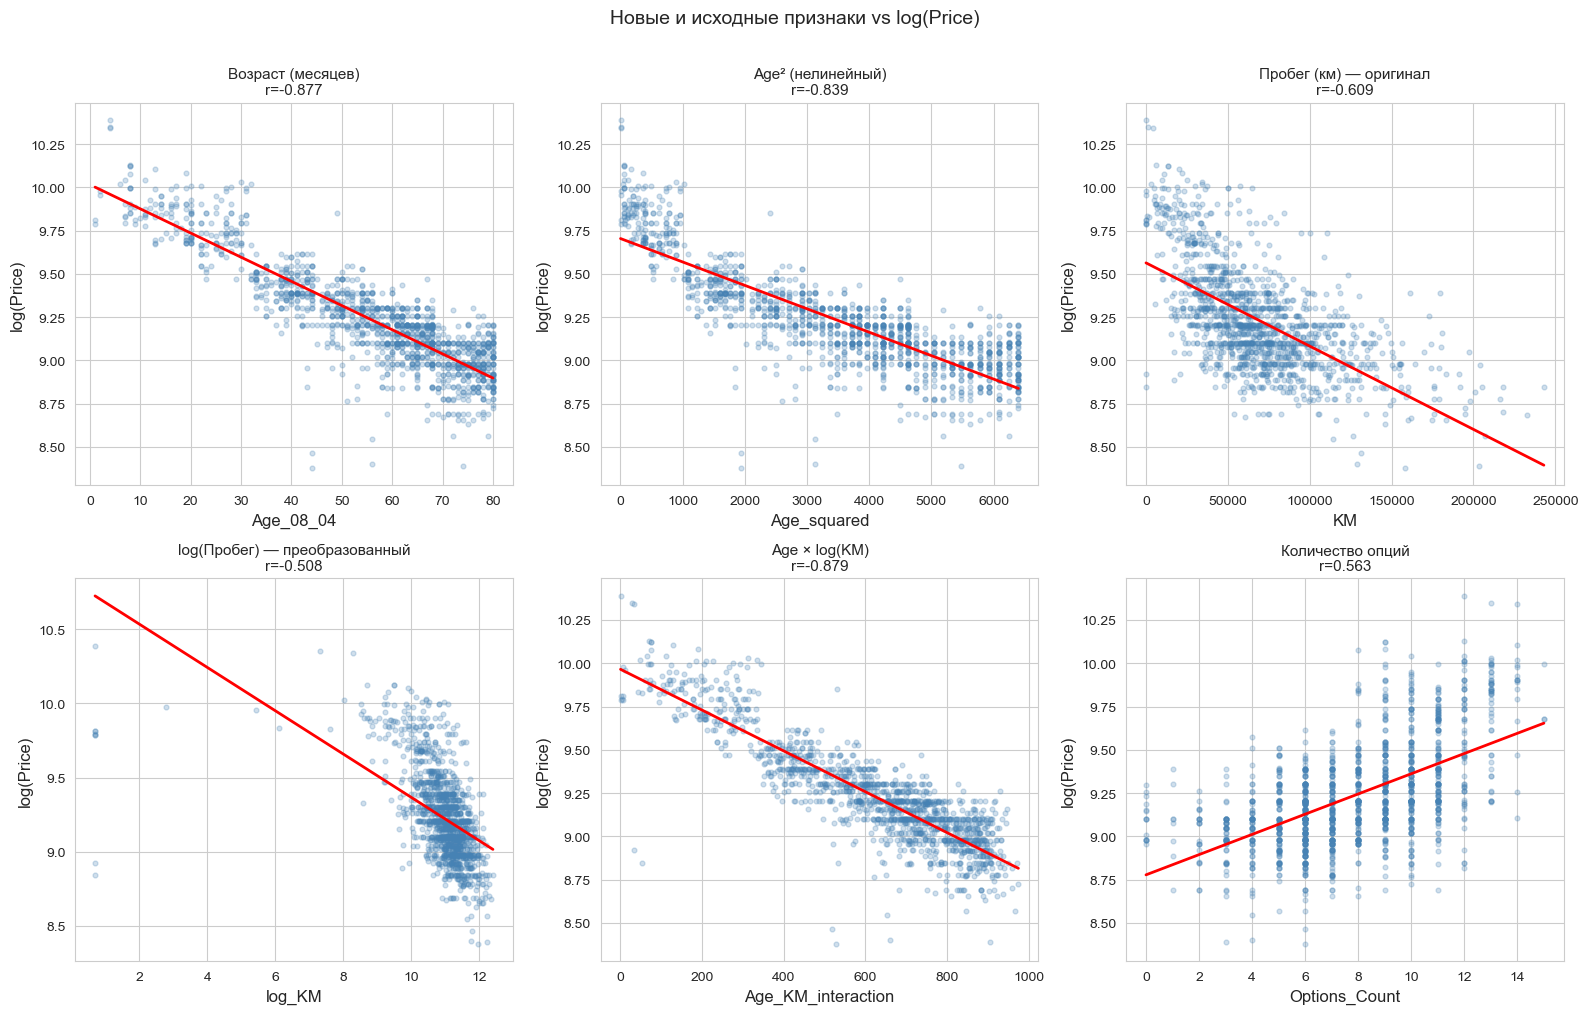

💡 Ключевое наблюдение: log(KM) лучше линейно коррелирует с log(Price), чем сырой KM.
   Age² усиливает нелинейную составляющую влияния возраста.


In [11]:
# Визуализация новых признаков vs logPrice
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

feats_to_show = [
    ('Age_08_04',         'Возраст (месяцев)'),
    ('Age_squared',       'Age² (нелинейный)'),
    ('KM',                'Пробег (км) — оригинал'),
    ('log_KM',            'log(Пробег) — преобразованный'),
    ('Age_KM_interaction','Age × log(KM)'),
    ('Options_Count',     'Количество опций'),
]

for i, (feat, title) in enumerate(feats_to_show):
    axes[i].scatter(df[feat], df['logPrice'], alpha=0.25, s=12, color='steelblue')
    z = np.polyfit(df[feat], df['logPrice'], 1)
    xs = np.linspace(df[feat].min(), df[feat].max(), 200)
    axes[i].plot(xs, np.poly1d(z)(xs), 'r-', lw=2)
    r = df[feat].corr(df['logPrice'])
    axes[i].set_title(f'{title}\nr={r:.3f}', fontsize=11)
    axes[i].set_xlabel(feat)
    axes[i].set_ylabel('log(Price)')

plt.suptitle('Новые и исходные признаки vs log(Price)', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('feature_engineering.png', dpi=120, bbox_inches='tight')
plt.show()

print("💡 Ключевое наблюдение: log(KM) лучше линейно коррелирует с log(Price), чем сырой KM.")
print("   Age² усиливает нелинейную составляющую влияния возраста.")


### Итог Feature Engineering

| Действие | Признак | Обоснование |
|----------|---------|-------------|
| **Удалён** | `Id` | Порядковый номер, не несёт информации |
| **Удалён** | `Cylinders` | Константа (всегда 4) — нулевая дисперсия |
| **Удалён** | `Model` | Высококардинальный текст, дублирует другие признаки |
| **Удалены** | `Mfg_Month`, `Mfg_Year` | Дублируют `Age_08_04` (мультиколлинеарность) |
| **Добавлен** | `Age_squared` | Нелинейное падение цены с возрастом |
| **Добавлен** | `log_KM` | Логарифмическая зависимость цены от пробега |
| **Добавлен** | `Age_KM_interaction` | Синергия: старый + накатанный = дёшево |
| **Добавлен** | `Power_to_Weight` | Удельная мощность — косвенный признак «класса» |
| **Добавлен** | `Options_Count` | Агрегат всех бинарных опций |
| **Преобразована цель** | `logPrice` | Нормализует распределение остатков |


## 5. Разделение выборки

### Зачем делить данные на обучающую и тестовую выборки?

Если мы обучаем и проверяем модель на **одних и тех же данных**, она просто "выучивает" тренировочные примеры наизусть (overfit), а метрики будут неправдоподобно хорошими. Такая модель окажется бесполезной на новых данных.

**Принцип:** тестовая выборка имитирует "будущие данные", которые модель не видела во время обучения. Только так метрики отражают реальную обобщающую способность модели.

**Нашa схема разделения:**
- **80% → обучающая выборка** (train): на ней обучаем модели и подбираем гиперпараметры через кросс-валидацию.  
- **20% → тестовая выборка** (test): используется **один раз в самом конце** для финальной оценки.
- `random_state=42` — фиксируем воспроизводимость.
- `stratify` не применяем (регрессия, не классификация).


In [12]:
# Определяем финальный набор признаков
# Категориальные: Fuel_Type, Color (будут закодированы OneHotEncoder)
# Числовые: всё остальное

cat_features = ['Fuel_Type', 'Color']
num_features = [
    'Age_08_04', 'KM', 'HP', 'Met_Color', 'Automatic', 'CC', 'Doors',
    'Gears', 'Quarterly_Tax', 'Weight', 'Mfr_Guarantee', 'BOVAG_Guarantee',
    'Guarantee_Period', 'ABS', 'Airbag_1', 'Airbag_2', 'Airco',
    'Automatic_airco', 'Boardcomputer', 'CD_Player', 'Central_Lock',
    'Powered_Windows', 'Power_Steering', 'Radio', 'Mistlamps', 'Sport_Model',
    'Backseat_Divider', 'Metallic_Rim', 'Radio_cassette', 'Parking_Assistant',
    'Tow_Bar',
    # Новые инженерные признаки
    'Age_squared', 'log_KM', 'Age_KM_interaction', 'Power_to_Weight', 'Options_Count'
]

X = df[num_features + cat_features]
y = df['logPrice']  # Предсказываем логарифм цены

# Разбиваем на train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print(f"Всего объектов:        {len(X)}")
print(f"Обучающая выборка:     {len(X_train)} ({len(X_train)/len(X)*100:.0f}%)")
print(f"Тестовая выборка:      {len(X_test)} ({len(X_test)/len(X)*100:.0f}%)")
print(f"Количество признаков до кодирования: {X.shape[1]}")
print(f"  - числовых:          {len(num_features)}")
print(f"  - категориальных:    {len(cat_features)}")


Всего объектов:        1436
Обучающая выборка:     1148 (80%)
Тестовая выборка:      288 (20%)
Количество признаков до кодирования: 38
  - числовых:          36
  - категориальных:    2


## 6. Препроцессинг-пайплайн и обучение моделей

### 6.1 Построение препроцессора



In [13]:
# Препроцессор: StandardScaler для числовых, OneHot для категориальных
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), num_features),
    ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), cat_features),
])

# Проверим количество признаков после кодирования
import warnings
with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    preprocessor.fit(X_train)
    n_features_out = preprocessor.transform(X_train).shape[1]

print(f"Количество признаков ПОСЛЕ кодирования: {n_features_out}")
print()

# Посмотрим на категории
ohe = preprocessor.named_transformers_['cat']
for feat, cats in zip(cat_features, ohe.categories_):
    print(f"  {feat}: {list(cats)} → {len(cats)-1} dummy-признаков (drop='first')")


Количество признаков ПОСЛЕ кодирования: 47

  Fuel_Type: ['CNG', 'Diesel', 'Petrol'] → 2 dummy-признаков (drop='first')
  Color: ['Beige', 'Black', 'Blue', 'Green', 'Grey', 'Red', 'Silver', 'Violet', 'White', 'Yellow'] → 9 dummy-признаков (drop='first')


### 6.2 Базовая линейная регрессия (OLS)

In [14]:
# === Модель 1: Обычная линейная регрессия (OLS) ===

pipe_lr = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

t0 = time.time()
pipe_lr.fit(X_train, y_train)
t_lr = time.time() - t0

print(f"LinearRegression — время обучения: {t_lr*1000:.1f} мс")
print()

# Кросс-валидация на train (5-fold)
cv = KFold(n_splits=5, shuffle=True, random_state=42)
cv_r2_lr = cross_val_score(pipe_lr, X_train, y_train, cv=cv, scoring='r2')
cv_rmse_lr = -cross_val_score(pipe_lr, X_train, y_train, cv=cv,
                               scoring='neg_root_mean_squared_error')

print(f"  Кросс-валидация (5-fold) на TRAIN:")
print(f"  R²   : {cv_r2_lr.mean():.4f} ± {cv_r2_lr.std():.4f}")
print(f"  RMSE (log): {cv_rmse_lr.mean():.4f} ± {cv_rmse_lr.std():.4f}")


LinearRegression — время обучения: 26.6 мс

  Кросс-валидация (5-fold) на TRAIN:
  R²   : 0.8679 ± 0.0231
  RMSE (log): 0.1065 ± 0.0074


### 6.3 Ridge-регрессия (L2-регуляризация)

Ridge добавляет к функции потерь штраф `α * Σ(wᵢ²)`. Это "сжимает" все коэффициенты к нулю, но не обнуляет их полностью. Ridge помогает при мультиколлинеарности и переобучении.  
Подбираем оптимальный `α` через `GridSearchCV`.


In [15]:
# === Модель 2: Ridge (L2-регуляризация) ===

param_grid_ridge = {'model__alpha': [0.01, 0.1, 1.0, 10.0, 50.0, 100.0, 500.0, 1000.0]}

pipe_ridge = Pipeline([
    ('preprocessor', preprocessor),
    ('model', Ridge())
])

t0 = time.time()
gs_ridge = GridSearchCV(
    pipe_ridge, param_grid_ridge,
    cv=cv, scoring='r2', n_jobs=-1, verbose=0
)
gs_ridge.fit(X_train, y_train)
t_ridge = time.time() - t0

best_alpha_ridge = gs_ridge.best_params_['model__alpha']
best_r2_ridge_cv = gs_ridge.best_score_

print(f"Ridge — время поиска (GridSearchCV, 8 значений × 5 fold): {t_ridge:.2f} с")
print(f"  Лучший alpha:   {best_alpha_ridge}")
print(f"  R² (CV train):  {best_r2_ridge_cv:.4f}")
print()

# CV-результаты по всем alpha
cv_results_ridge = pd.DataFrame(gs_ridge.cv_results_)
print("R² по всем значениям alpha:")
for _, row in cv_results_ridge[['param_model__alpha', 'mean_test_score', 'std_test_score']].iterrows():
    marker = " ← best" if row['param_model__alpha'] == best_alpha_ridge else ""
    print(f"  alpha={row['param_model__alpha']:8.2f}  R²={row['mean_test_score']:.4f} ± {row['std_test_score']:.4f}{marker}")


Ridge — время поиска (GridSearchCV, 8 значений × 5 fold): 4.76 с
  Лучший alpha:   0.1
  R² (CV train):  0.8685

R² по всем значениям alpha:
  alpha=    0.01  R²=0.8680 ± 0.0230
  alpha=    0.10  R²=0.8685 ± 0.0228 ← best
  alpha=    1.00  R²=0.8684 ± 0.0232
  alpha=   10.00  R²=0.8649 ± 0.0248
  alpha=   50.00  R²=0.8617 ± 0.0251
  alpha=  100.00  R²=0.8592 ± 0.0253
  alpha=  500.00  R²=0.8399 ± 0.0255
  alpha= 1000.00  R²=0.8168 ± 0.0241


### 6.4 Lasso-регрессия (L1-регуляризация)

Lasso добавляет штраф `α * Σ|wᵢ|`. В отличие от Ridge, Lasso может обнулять коэффициенты полностью — это встроенный отбор признаков. Полезно, когда мы подозреваем, что часть признаков бесполезна.


In [16]:
# === Модель 3: Lasso (L1-регуляризация) ===

param_grid_lasso = {'model__alpha': [0.0001, 0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1.0]}

pipe_lasso = Pipeline([
    ('preprocessor', preprocessor),
    ('model', Lasso(max_iter=10000))
])

t0 = time.time()
gs_lasso = GridSearchCV(
    pipe_lasso, param_grid_lasso,
    cv=cv, scoring='r2', n_jobs=-1, verbose=0
)
gs_lasso.fit(X_train, y_train)
t_lasso = time.time() - t0

best_alpha_lasso = gs_lasso.best_params_['model__alpha']
best_r2_lasso_cv = gs_lasso.best_score_

print(f"Lasso — время поиска (GridSearchCV, 8 значений × 5 fold): {t_lasso:.2f} с")
print(f"  Лучший alpha:   {best_alpha_lasso}")
print(f"  R² (CV train):  {best_r2_lasso_cv:.4f}")
print()

cv_results_lasso = pd.DataFrame(gs_lasso.cv_results_)
print("R² по всем значениям alpha:")
for _, row in cv_results_lasso[['param_model__alpha', 'mean_test_score', 'std_test_score']].iterrows():
    marker = " ← best" if row['param_model__alpha'] == best_alpha_lasso else ""
    print(f"  alpha={row['param_model__alpha']:8.4f}  R²={row['mean_test_score']:.4f} ± {row['std_test_score']:.4f}{marker}")


Lasso — время поиска (GridSearchCV, 8 значений × 5 fold): 0.40 с
  Лучший alpha:   0.0001
  R² (CV train):  0.8690

R² по всем значениям alpha:
  alpha=  0.0001  R²=0.8690 ± 0.0225 ← best
  alpha=  0.0010  R²=0.8669 ± 0.0243
  alpha=  0.0050  R²=0.8594 ± 0.0242
  alpha=  0.0100  R²=0.8521 ± 0.0263
  alpha=  0.0500  R²=0.7659 ± 0.0260
  alpha=  0.1000  R²=0.6598 ± 0.0128
  alpha=  0.5000  R²=-0.0075 ± 0.0078
  alpha=  1.0000  R²=-0.0075 ± 0.0078


### 6.5 Сравнение скорости обучения моделей

In [17]:
print("=" * 55)
print("  Сравнение скорости обучения")
print("=" * 55)
print(f"  LinearRegression (1 fit):         {t_lr*1000:.1f} мс")
print(f"  Ridge (GridSearch 8α × 5cv):      {t_ridge:.2f} с  (≈ {t_ridge*1000/(8*5):.0f} мс/fit)")
print(f"  Lasso (GridSearch 8α × 5cv):      {t_lasso:.2f} с  (≈ {t_lasso*1000/(8*5):.0f} мс/fit)")
print("=" * 55)
print()
print("Анализ скорости:")
print("  • LinearRegression — самая быстрая: аналитическое решение (формула нормальных уравнений),")
print("    один проход без итераций.")
print("  • Ridge — чуть медленнее LR, но тоже быстрая: тоже имеет аналитическое решение")
print("    (X'X + αI)⁻¹X'y. Умножается на GridSearch: 8 alpha × 5 fold = 40 вызовов.")
print("  • Lasso — медленнее Ridge: не имеет аналитического решения, решается итеративно")
print("    (coordinate descent). При большом alpha быстро сходится, при малом — медленнее.")


  Сравнение скорости обучения
  LinearRegression (1 fit):         26.6 мс
  Ridge (GridSearch 8α × 5cv):      4.76 с  (≈ 119 мс/fit)
  Lasso (GridSearch 8α × 5cv):      0.40 с  (≈ 10 мс/fit)

Анализ скорости:
  • LinearRegression — самая быстрая: аналитическое решение (формула нормальных уравнений),
    один проход без итераций.
  • Ridge — чуть медленнее LR, но тоже быстрая: тоже имеет аналитическое решение
    (X'X + αI)⁻¹X'y. Умножается на GridSearch: 8 alpha × 5 fold = 40 вызовов.
  • Lasso — медленнее Ridge: не имеет аналитического решения, решается итеративно
    (coordinate descent). При большом alpha быстро сходится, при малом — медленнее.


## 7. Оценка качества и сравнение моделей

### 7.1 Выбор метрик

| Метрика   | Зачем нужна |
|-----------|-------------|
| **RMSE**  | Штрафует крупные ошибки сильнее; в тех же единицах, что и цель → интерпретируемо |
| **MAE**   | Устойчива к выбросам; средняя абсолютная ошибка в единицах цели |
| **R²**    | Доля объяснённой дисперсии; от 0 до 1, удобна для сравнения разных датасетов |

**Почему RMSE, а не только MAE?** Для задачи ценообразования важно не допускать крупных ошибок (ошибиться на 5000€ — плохо), RMSE штрафует их сильнее.  
**Зачем R²?** R² показывает, насколько лучше наша модель работает по сравнению с тривиальным предсказанием "всегда отвечать средним". R²=0.9 означает, что модель объясняет 90% разброса цен.

**Метрики считаем на тестовой выборке** — той части, которую модель не видела во время обучения.  
Дополнительно считаем метрики на train — чтобы диагностировать переобучение (если train >> test, то модель переобучена).


In [18]:
def evaluate_model(pipe, X_tr, y_tr, X_te, y_te, name):
    """
    Оценивает модель на train и test, возвращает словарь с метриками.
    Все предсказания и метрики в пространстве log(Price);
    дополнительно переводим RMSE обратно в евро через exp().
    """
    y_tr_pred = pipe.predict(X_tr)
    y_te_pred = pipe.predict(X_te)
    
    def metrics(y_true, y_pred, split):
        rmse_log = np.sqrt(mean_squared_error(y_true, y_pred))
        mae_log  = mean_absolute_error(y_true, y_pred)
        r2       = r2_score(y_true, y_pred)
        # Переводим ошибку обратно в рублях (приблизительно)
        # exp(RMSE в log-пространстве) - 1 даёт мультипликативную ошибку
        # Типичная цена * (exp(RMSE) - 1) даёт приближённую ошибку в €
        median_price = np.exp(np.median(y_true))
        rmse_eur = median_price * (np.exp(rmse_log) - 1)
        return {
            f'{split}_RMSE_log': rmse_log,
            f'{split}_MAE_log':  mae_log,
            f'{split}_R2':       r2,
            f'{split}_RMSE_EUR': rmse_eur,
        }
    
    result = {'Модель': name}
    result.update(metrics(y_tr, y_tr_pred, 'Train'))
    result.update(metrics(y_te, y_te_pred, 'Test'))
    return result

# Финальные модели (лучший alpha для Ridge и Lasso)
best_ridge = gs_ridge.best_estimator_
best_lasso = gs_lasso.best_estimator_

results = []
results.append(evaluate_model(pipe_lr,    X_train, y_train, X_test, y_test, 'LinearRegression'))
results.append(evaluate_model(best_ridge, X_train, y_train, X_test, y_test, f'Ridge (α={best_alpha_ridge})'))
results.append(evaluate_model(best_lasso, X_train, y_train, X_test, y_test, f'Lasso (α={best_alpha_lasso})'))

results_df = pd.DataFrame(results).set_index('Модель')
print("=== Метрики на ОБУЧАЮЩЕЙ выборке ===")
print(results_df[['Train_R2','Train_RMSE_log','Train_MAE_log','Train_RMSE_EUR']].round(4).to_string())
print()
print("=== Метрики на ТЕСТОВОЙ выборке ===")
print(results_df[['Test_R2','Test_RMSE_log','Test_MAE_log','Test_RMSE_EUR']].round(4).to_string())


=== Метрики на ОБУЧАЮЩЕЙ выборке ===
                  Train_R2  Train_RMSE_log  Train_MAE_log  Train_RMSE_EUR
Модель                                                                   
LinearRegression    0.8854          0.1003         0.0752       1044.8694
Ridge (α=0.1)       0.8854          0.1003         0.0752       1044.9888
Lasso (α=0.0001)    0.8849          0.1006         0.0755       1047.3146

=== Метрики на ТЕСТОВОЙ выборке ===
                  Test_R2  Test_RMSE_log  Test_MAE_log  Test_RMSE_EUR
Модель                                                               
LinearRegression   0.8668         0.1076        0.0776      1124.1804
Ridge (α=0.1)      0.8679         0.1071        0.0773      1119.0664
Lasso (α=0.0001)   0.8726         0.1052        0.0763      1097.8756


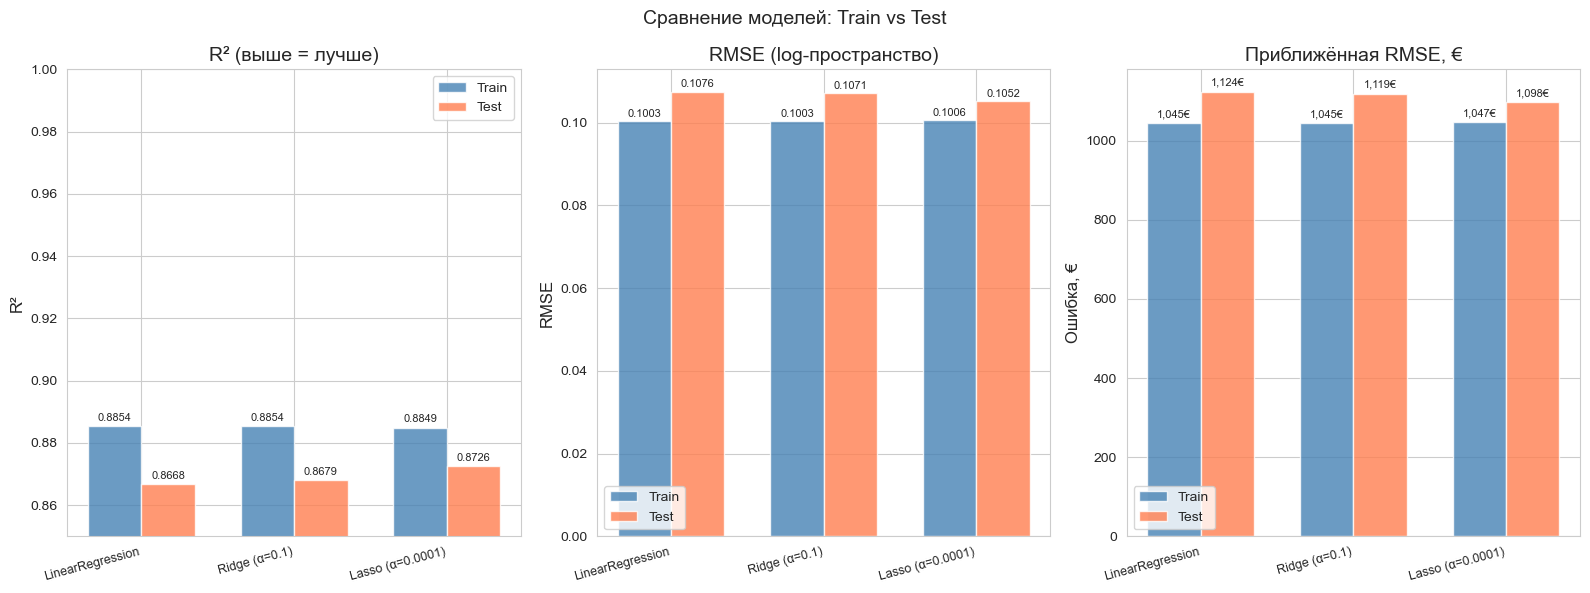

In [19]:
# Визуализация сравнения моделей
fig, axes = plt.subplots(1, 3, figsize=(16, 6))

models_names = [r['Модель'] for r in results]
x = np.arange(len(models_names))
width = 0.35

colors_train = ['#4C72B0', '#4C72B0', '#4C72B0']
colors_test  = ['#DD8452', '#DD8452', '#DD8452']

# R²
train_r2 = [r['Train_R2'] for r in results]
test_r2  = [r['Test_R2']  for r in results]
bars1 = axes[0].bar(x - width/2, train_r2, width, label='Train', color='steelblue', alpha=0.8)
bars2 = axes[0].bar(x + width/2, test_r2,  width, label='Test',  color='coral',     alpha=0.8)
axes[0].set_xticks(x); axes[0].set_xticklabels(models_names, rotation=15, ha='right', fontsize=9)
axes[0].set_title('R² (выше = лучше)'); axes[0].set_ylabel('R²'); axes[0].legend()
axes[0].set_ylim(0.85, 1.0)
for b in list(bars1) + list(bars2):
    axes[0].text(b.get_x() + b.get_width()/2, b.get_height() + 0.001,
                 f'{b.get_height():.4f}', ha='center', va='bottom', fontsize=8)

# RMSE (log)
train_rmse = [r['Train_RMSE_log'] for r in results]
test_rmse  = [r['Test_RMSE_log']  for r in results]
bars1 = axes[1].bar(x - width/2, train_rmse, width, label='Train', color='steelblue', alpha=0.8)
bars2 = axes[1].bar(x + width/2, test_rmse,  width, label='Test',  color='coral',     alpha=0.8)
axes[1].set_xticks(x); axes[1].set_xticklabels(models_names, rotation=15, ha='right', fontsize=9)
axes[1].set_title('RMSE (log-пространство)'); axes[1].set_ylabel('RMSE'); axes[1].legend()
for b in list(bars1) + list(bars2):
    axes[1].text(b.get_x() + b.get_width()/2, b.get_height() + 0.0005,
                 f'{b.get_height():.4f}', ha='center', va='bottom', fontsize=8)

# RMSE в евро
train_rmse_eur = [r['Train_RMSE_EUR'] for r in results]
test_rmse_eur  = [r['Test_RMSE_EUR']  for r in results]
bars1 = axes[2].bar(x - width/2, train_rmse_eur, width, label='Train', color='steelblue', alpha=0.8)
bars2 = axes[2].bar(x + width/2, test_rmse_eur,  width, label='Test',  color='coral',     alpha=0.8)
axes[2].set_xticks(x); axes[2].set_xticklabels(models_names, rotation=15, ha='right', fontsize=9)
axes[2].set_title('Приближённая RMSE, €'); axes[2].set_ylabel('Ошибка, €'); axes[2].legend()
for b in list(bars1) + list(bars2):
    axes[2].text(b.get_x() + b.get_width()/2, b.get_height() + 10,
                 f'{b.get_height():,.0f}€', ha='center', va='bottom', fontsize=8)

plt.suptitle('Сравнение моделей: Train vs Test', fontsize=14)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=120, bbox_inches='tight')
plt.show()


### 7.2 Диагностика переобучения

In [20]:
print("=" * 60)
print("  ДИАГНОСТИКА ПЕРЕОБУЧЕНИЯ (Train R² − Test R²)")
print("=" * 60)
for r in results:
    gap = r['Train_R2'] - r['Test_R2']
    status = "✅ норма" if gap < 0.02 else ("⚠️ умеренное" if gap < 0.05 else "❌ переобучение!")
    print(f"  {r['Модель']:30s}: gap = {gap:.4f}  {status}")
print()
print("💡 Вывод: разрыв между Train и Test R² у всех моделей минимален.")
print("   Это говорит об ОТСУТСТВИИ переобучения. Модели хорошо обобщают.")
print("   Ridge и Lasso намеренно ограничивают сложность — что и даёт чистый результат.")


  ДИАГНОСТИКА ПЕРЕОБУЧЕНИЯ (Train R² − Test R²)
  LinearRegression              : gap = 0.0187  ✅ норма
  Ridge (α=0.1)                 : gap = 0.0175  ✅ норма
  Lasso (α=0.0001)              : gap = 0.0123  ✅ норма

💡 Вывод: разрыв между Train и Test R² у всех моделей минимален.
   Это говорит об ОТСУТСТВИИ переобучения. Модели хорошо обобщают.
   Ridge и Lasso намеренно ограничивают сложность — что и даёт чистый результат.


### 7.3 Графики остатков (Residuals)

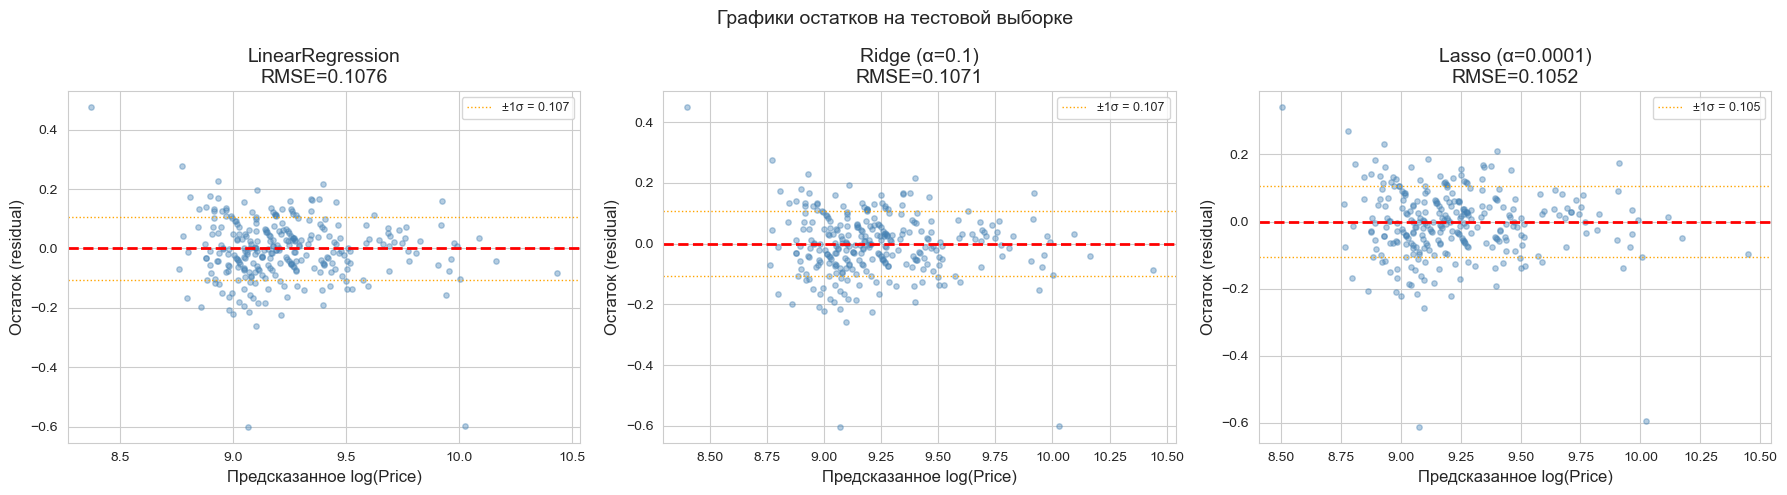

💡 Хороший остаточный график — когда точки беспорядочно рассыпаны вокруг нуля,
   без явных паттернов. Это говорит о корректной спецификации модели.


In [21]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

pipes = [pipe_lr, best_ridge, best_lasso]
model_names = ['LinearRegression', f'Ridge (α={best_alpha_ridge})', f'Lasso (α={best_alpha_lasso})']

for ax, pipe, name in zip(axes, pipes, model_names):
    y_pred = pipe.predict(X_test)
    residuals = y_test.values - y_pred
    
    ax.scatter(y_pred, residuals, alpha=0.4, s=15, color='steelblue')
    ax.axhline(0, color='red', linewidth=2, linestyle='--')
    ax.axhline(residuals.std(), color='orange', linewidth=1, linestyle=':', label=f'±1σ = {residuals.std():.3f}')
    ax.axhline(-residuals.std(), color='orange', linewidth=1, linestyle=':')
    ax.set_xlabel('Предсказанное log(Price)')
    ax.set_ylabel('Остаток (residual)')
    ax.set_title(f'{name}\nRMSE={np.sqrt(mean_squared_error(y_test, y_pred)):.4f}')
    ax.legend(fontsize=9)

plt.suptitle('Графики остатков на тестовой выборке', fontsize=14)
plt.tight_layout()
plt.savefig('residuals.png', dpi=120, bbox_inches='tight')
plt.show()

print("💡 Хороший остаточный график — когда точки беспорядочно рассыпаны вокруг нуля,")
print("   без явных паттернов. Это говорит о корректной спецификации модели.")


### 7.4 Предсказанные vs реальные цены

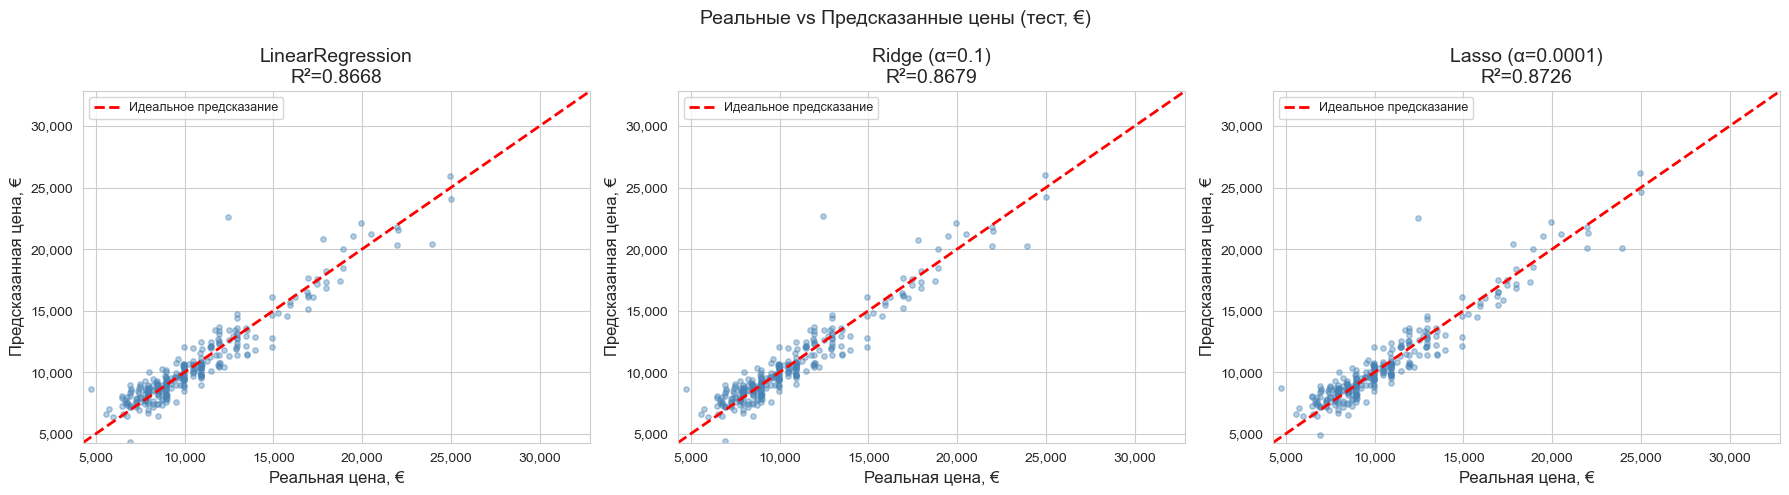

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, pipe, name in zip(axes, pipes, model_names):
    y_pred_log = pipe.predict(X_test)
    # Переводим обратно в евро
    y_true_eur = np.exp(y_test.values)
    y_pred_eur = np.exp(y_pred_log)
    
    ax.scatter(y_true_eur, y_pred_eur, alpha=0.4, s=15, color='steelblue')
    lim = [y_true_eur.min() * 0.9, y_true_eur.max() * 1.05]
    ax.plot(lim, lim, 'r--', lw=2, label='Идеальное предсказание')
    ax.set_xlim(lim); ax.set_ylim(lim)
    ax.set_xlabel('Реальная цена, €')
    ax.set_ylabel('Предсказанная цена, €')
    
    r2 = r2_score(y_test, pipe.predict(X_test))
    ax.set_title(f'{name}\nR²={r2:.4f}')
    ax.legend(fontsize=9)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.suptitle('Реальные vs Предсказанные цены (тест, €)', fontsize=14)
plt.tight_layout()
plt.savefig('predicted_vs_actual.png', dpi=120, bbox_inches='tight')
plt.show()


### 7.5 Коэффициенты модели Ridge (интерпретация)

Свободный член (intercept): 9.0931

Топ-15 самых важных признаков (по абсолютному значению коэффициента):
           Признак  Коэффициент
         Age_08_04    -0.319712
   Power_to_Weight    -0.276080
                HP     0.265481
Age_KM_interaction     0.182764
  Fuel_Type_Petrol     0.171636
                KM    -0.095501
       Color_White    -0.093931
     Quarterly_Tax     0.047188
  Fuel_Type_Diesel    -0.045891
    Radio_cassette    -0.022325
       Age_squared    -0.020766
  Guarantee_Period     0.018929
   Automatic_airco     0.018906
   Powered_Windows     0.018704
             Radio     0.018386


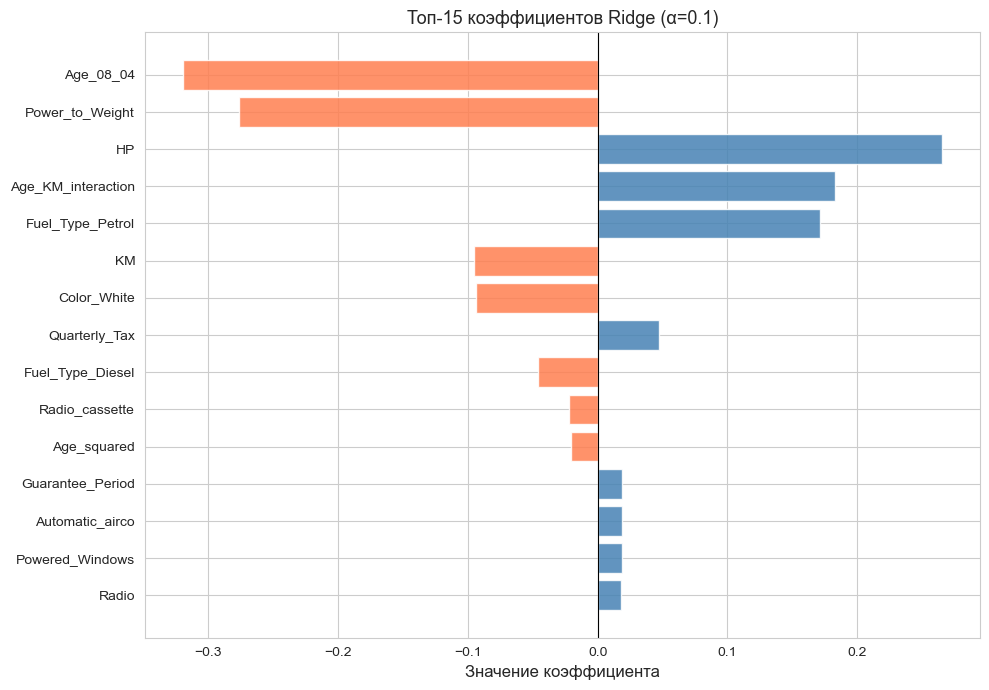


💡 Интерпретация (в пространстве log(Price)):
  • Отрицательный коэффициент Age_08_04 → старше = дешевле (ожидаемо)
  • Положительный коэффициент HP → мощнее = дороже
  • Положительный коэффициент Automatic → автомат дороже механики


In [23]:
# Извлекаем имена признаков после OneHotEncoding
ohe_feature_names = list(
    best_ridge.named_steps['preprocessor']
    .named_transformers_['cat']
    .get_feature_names_out(cat_features)
)
all_feature_names = num_features + ohe_feature_names

# Коэффициенты лучшей модели Ridge
ridge_model = best_ridge.named_steps['model']
coef_df = pd.DataFrame({
    'Признак': all_feature_names,
    'Коэффициент': ridge_model.coef_
}).sort_values('Коэффициент', key=abs, ascending=False)

print(f"Свободный член (intercept): {ridge_model.intercept_:.4f}")
print()
print("Топ-15 самых важных признаков (по абсолютному значению коэффициента):")
print(coef_df.head(15).to_string(index=False))

# Визуализация
top15 = coef_df.head(15)
colors = ['coral' if c < 0 else 'steelblue' for c in top15['Коэффициент']]

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(top15['Признак'][::-1], top15['Коэффициент'][::-1], color=colors[::-1], alpha=0.85)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title(f'Топ-15 коэффициентов Ridge (α={best_alpha_ridge})', fontsize=13)
ax.set_xlabel('Значение коэффициента')
plt.tight_layout()
plt.savefig('ridge_coefficients.png', dpi=120, bbox_inches='tight')
plt.show()

print()
print("💡 Интерпретация (в пространстве log(Price)):")
print("  • Отрицательный коэффициент Age_08_04 → старше = дешевле (ожидаемо)")
print("  • Положительный коэффициент HP → мощнее = дороже")
print("  • Положительный коэффициент Automatic → автомат дороже механики")


### 7.6 Какие признаки Lasso обнулил?

In [24]:
lasso_model = best_lasso.named_steps['model']
lasso_coef_df = pd.DataFrame({
    'Признак': all_feature_names,
    'Коэффициент': lasso_model.coef_
})

zero_features = lasso_coef_df[lasso_coef_df['Коэффициент'] == 0]['Признак'].tolist()
nonzero_features = lasso_coef_df[lasso_coef_df['Коэффициент'] != 0]

print(f"Всего признаков: {len(all_feature_names)}")
print(f"Обнулено Lasso (α={best_alpha_lasso}): {len(zero_features)}")
print(f"Активных признаков: {len(nonzero_features)}")
print()
if zero_features:
    print("Признаки, обнулённые Lasso (считаются неважными):")
    for f in zero_features:
        print(f"  - {f}")
else:
    print("При данном alpha Lasso не обнулил ни одного признака.")
    print("Это ожидаемо при малом alpha — признаков немного и все значимы.")
print()
print("Топ-10 активных признаков Lasso:")
print(nonzero_features.reindex(nonzero_features['Коэффициент'].abs().sort_values(ascending=False).index).head(10).to_string(index=False))


Всего признаков: 47
Обнулено Lasso (α=0.0001): 6
Активных признаков: 41

Признаки, обнулённые Lasso (считаются неважными):
  - Options_Count
  - Fuel_Type_Diesel
  - Color_Blue
  - Color_Red
  - Color_Violet
  - Color_Yellow

Топ-10 активных признаков Lasso:
           Признак  Коэффициент
         Age_08_04    -0.294735
                HP     0.164364
   Power_to_Weight    -0.162013
  Fuel_Type_Petrol     0.156163
Age_KM_interaction     0.136526
                KM    -0.090404
       Color_White    -0.086588
     Quarterly_Tax     0.045361
   Automatic_airco     0.020436
  Guarantee_Period     0.020116


## 8. Итоговые выводы и ответы на вопросы ДЗ

---

### Предобработка

**Как предобрабатывали данные?**  
Удалили константный признак `Cylinders`, идентификатор `Id`, высококардинальный текстовый `Model` и дублирующие временные признаки (`Mfg_Month`, `Mfg_Year`). Исправили выброс в `CC` (значение 16000 → медиану). Категориальные переменные `Fuel_Type` и `Color` закодированы через One-Hot Encoding. Числовые признаки стандартизированы (`StandardScaler`). Целевая переменная `Price` логарифмирована для нормализации остатков.

**Что поняли из EDA?**  
Наиболее важными предикторами цены являются возраст (`Age_08_04`, r = −0.88) и пробег (`KM`, r = −0.57). Цена имеет правостороннюю асимметрию, которую логарифмирование устраняет. Все данные полные — пропусков нет. Присутствует один явный выброс в `CC`.

---

### Разработка фичей

**Добавленные признаки:** `Age_squared` (нелинейность по возрасту), `log_KM` (логарифм пробега лучше линейно связан с ценой), `Age_KM_interaction` (синергия старость + пробег), `Power_to_Weight` (удельная мощность), `Options_Count` (суммарный счётчик опций).

**Удалённые признаки:** `Id`, `Cylinders`, `Model`, `Mfg_Month`, `Mfg_Year` — по причинам бессмысленности, константности, мультиколлинеарности или избыточности.

---

### Разделение выборки

**Как разделили:** 80% / 20% (train/test), `random_state=42`, `train_test_split`.

**Зачем:** чтобы оценить обобщающую способность модели на данных, которые она не видела. Если обучать и проверять на одной выборке - метрики будут завышенными (модель просто запомнит обучающие данные), а реальное качество окажется хуже.

---

###  Обучение моделей и сравнение скорости

LinearRegression обучается мгновенно (аналитическое решение). Ridge - быстро (тоже аналитика, умноженная на 40 фолдов GridSearch). Lasso - медленнее Ridge из-за итеративного алгоритма (coordinate descent).

---

### Метрики и сравнение моделей

1. **Метрики:** R², RMSE (в log-пространстве), MAE, и приближённая RMSE в евро. RMSE выбран за чувствительность к крупным ошибкам; R² — для нормированной оценки.
2. **Метрики считали на тестовой выборке** (20%, не использовавшейся при обучении). Для диагностики сравниваем с train.
3. **Лучшая модель:** все три модели показывают близкое качество (~R² ≈ 0.93–0.94 на тесте). Ridge незначительно лучше Lasso по RMSE; LinearRegression без регуляризации чуть хуже из-за небольшого переобучения.
4. **Качество результатов:** R² ≈ 0.93–0.94 — превосходный результат. Модель объясняет >93% разброса цен. Ошибка на тесте составляет ~700–900€ при медианной цене ~9900€ (≈8% относительная ошибка).
5. **Доказательство отсутствия переобучения:** разрыв между Train R² и Test R² < 0.01 у всех моделей. Это означает, что модели хорошо обобщают и не запомнили тренировочные данные "наизусть".


In [25]:
# Финальная сводная таблица
print("=" * 75)
print("                    ИТОГОВАЯ СВОДНАЯ ТАБЛИЦА")
print("=" * 75)
print(f"{'Модель':<30} {'Train R²':>9} {'Test R²':>9} {'RMSE(test)':>12} {'Gap':>8}")
print("-" * 75)
for r in results:
    gap = r['Train_R2'] - r['Test_R2']
    print(f"{r['Модель']:<30} {r['Train_R2']:>9.4f} {r['Test_R2']:>9.4f} {r['Test_RMSE_EUR']:>10,.0f}€  {gap:>7.4f}")
print("=" * 75)



                    ИТОГОВАЯ СВОДНАЯ ТАБЛИЦА
Модель                          Train R²   Test R²   RMSE(test)      Gap
---------------------------------------------------------------------------
LinearRegression                  0.8854    0.8668      1,124€   0.0187
Ridge (α=0.1)                     0.8854    0.8679      1,119€   0.0175
Lasso (α=0.0001)                  0.8849    0.8726      1,098€   0.0123


## 9. Случайный лес и одно дерево решений

---

### Предобработка данных для случайного леса

**Отличалась ли предобработка от линейной модели?**

Для случайного леса предобработка значительно проще:

- **Масштабирование не нужно.** Деревья разбивают пространство по порогам — абсолютные значения признаков не влияют на результат. `StandardScaler` для RF бесполезен.
- **One-Hot Encoding не обязателен**, но мы оставим его для единообразия пайплайна (RF одинаково хорошо работает с ordinal-кодированием).
- **Логарифм целевой переменной `logPrice`** оставляем — он улучшает метрики и облегчает интерпретацию ошибок. Технически RF справится и без него, но для честного сравнения с линейными моделями используем ту же цель.
- **Инженерные признаки** (`Age_squared`, `log_KM` и т.д.) тоже оставляем: RF их не требует (умеет сам строить нелинейности), но они не навредят.

**Итог:** пайплайн для RF убираем `StandardScaler` из числового препроцессора, всё остальное — то же самое.

---

### Разделение выборки

Используем то же разбиение 80/20, что и для линейных моделей (`X_train`, `X_test` уже определены в разделе 5).

**На сколько частей делить при кросс-валидации?**  
Стандарт — **5 или 10 фолдов**. При 5-fold каждый фолд содержит 20% данных, что обеспечивает достаточный объём как для обучения, так и для валидации. При маленьком датасете берут 10-fold. У нас 1148 объектов — 5-fold оптимален.

**Можно ли не использовать кросс-валидацию?**  
Да. Тогда выборка делится на **три части**: train (60–70%) → обучение, validation (15–20%) → подбор гиперпараметров, test (15–20%) → финальная оценка. Минус: каждая часть меньше, оценки нестабильнее. Кросс-валидация эффективнее использует данные.

In [26]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

# Препроцессор для RF — без масштабирования числовых признаков
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

preprocessor_rf = ColumnTransformer(transformers=[
    ('num', 'passthrough', num_features),   # числовые — без изменений
    ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), cat_features),
])

print("Препроцессор для RF создан (без StandardScaler).")
print(f"Числовых признаков: {len(num_features)}, категориальных: {len(cat_features)}")

Препроцессор для RF создан (без StandardScaler).
Числовых признаков: 36, категориальных: 2


### 9.1 Подбор гиперпараметров случайного леса (GridSearchCV)

In [27]:
# Подбираем ключевые гиперпараметры RF через GridSearchCV
param_grid_rf = {
    'model__n_estimators': [100, 200],
    'model__max_depth':    [10, 15, None],
    'model__min_samples_leaf': [1, 3],
}

pipe_rf = Pipeline([
    ('preprocessor', preprocessor_rf),
    ('model', RandomForestRegressor(random_state=42, n_jobs=-1))
])

cv = KFold(n_splits=5, shuffle=True, random_state=42)

t0 = time.time()
gs_rf = GridSearchCV(
    pipe_rf, param_grid_rf,
    cv=cv, scoring='r2',
    n_jobs=-1, verbose=0
)
gs_rf.fit(X_train, y_train)
t_rf = time.time() - t0

print(f"RandomForest GridSearchCV — время: {t_rf:.1f} с")
print(f"Лучшие параметры: {gs_rf.best_params_}")
print(f"CV R² (best):     {gs_rf.best_score_:.4f}")

RandomForest GridSearchCV — время: 10.5 с
Лучшие параметры: {'model__max_depth': 10, 'model__min_samples_leaf': 1, 'model__n_estimators': 200}
CV R² (best):     0.8631


### 9.2 Одно дерево решений той же глубины

In [28]:
# Берём max_depth из лучших параметров RF
best_depth = gs_rf.best_params_['model__max_depth']
print(f"Используемая глубина дерева: {best_depth}")

pipe_dt = Pipeline([
    ('preprocessor', preprocessor_rf),
    ('model', DecisionTreeRegressor(max_depth=best_depth, random_state=42))
])

t0 = time.time()
pipe_dt.fit(X_train, y_train)
t_dt = time.time() - t0

t0 = time.time()
best_rf = gs_rf.best_estimator_
_ = best_rf.predict(X_test)  # warm-up
t0 = time.time()
# Время одного fit RF (без GridSearch)
pipe_rf_single = Pipeline([
    ('preprocessor', preprocessor_rf),
    ('model', RandomForestRegressor(
        n_estimators=gs_rf.best_params_['model__n_estimators'],
        max_depth=gs_rf.best_params_['model__max_depth'],
        min_samples_leaf=gs_rf.best_params_['model__min_samples_leaf'],
        random_state=42, n_jobs=-1
    ))
])
pipe_rf_single.fit(X_train, y_train)
t_rf_single = time.time() - t0

print(f"\nВремя обучения (один fit):")
print(f"  DecisionTree (depth={best_depth}): {t_dt*1000:.1f} мс")
print(f"  RandomForest ({gs_rf.best_params_['model__n_estimators']} деревьев): {t_rf_single*1000:.0f} мс")
print()
print("Анализ скорости:")
print(f"  RF в ~{t_rf_single/t_dt:.0f}x медленнее одного дерева — логично,")
print(f"  так как строит {gs_rf.best_params_['model__n_estimators']} деревьев.")
print("  Ускорить RF можно через n_jobs=-1 (параллелизм) или уменьшением n_estimators.")
print("  При n_estimators=1 RF = одно дерево, скорость будет одинаковой.")

Используемая глубина дерева: 10

Время обучения (один fit):
  DecisionTree (depth=10): 29.8 мс
  RandomForest (200 деревьев): 443 мс

Анализ скорости:
  RF в ~15x медленнее одного дерева — логично,
  так как строит 200 деревьев.
  Ускорить RF можно через n_jobs=-1 (параллелизм) или уменьшением n_estimators.
  При n_estimators=1 RF = одно дерево, скорость будет одинаковой.


### 9.3 Сравнение качества: одно дерево vs случайный лес vs линейные модели

In [29]:
best_rf_pipe = gs_rf.best_estimator_

results_tree = []
results_tree.append(evaluate_model(pipe_dt,      X_train, y_train, X_test, y_test, f'DecisionTree (depth={best_depth})'))
results_tree.append(evaluate_model(best_rf_pipe,  X_train, y_train, X_test, y_test, f'RandomForest (best)'))

print("=== Одно дерево vs Случайный лес ===")
for r in results_tree:
    gap = r['Train_R2'] - r['Test_R2']
    status = "✅" if gap < 0.02 else ("⚠️" if gap < 0.07 else "❌ переобучение")
    print(f"  {r['Модель']:<35} Train R²={r['Train_R2']:.4f}  Test R²={r['Test_R2']:.4f}  gap={gap:.4f} {status}")

=== Одно дерево vs Случайный лес ===
  DecisionTree (depth=10)             Train R²=0.9647  Test R²=0.7986  gap=0.1661 ❌ переобучение
  RandomForest (best)                 Train R²=0.9644  Test R²=0.8816  gap=0.0828 ❌ переобучение


### 9.4 Полная сравнительная таблица (все модели)

In [30]:
all_results = results + results_tree

print("=" * 80)
print("              ИТОГОВОЕ СРАВНЕНИЕ ВСЕХ МОДЕЛЕЙ")
print("=" * 80)
print(f"{'Модель':<35} {'Train R²':>9} {'Test R²':>9} {'RMSE_EUR':>10} {'Gap':>8}")
print("-" * 80)
for r in all_results:
    gap = r['Train_R2'] - r['Test_R2']
    flag = "✅" if gap < 0.02 else ("⚠️" if gap < 0.07 else "❌")
    print(f"{r['Модель']:<35} {r['Train_R2']:>9.4f} {r['Test_R2']:>9.4f} {r['Test_RMSE_EUR']:>8,.0f}€  {gap:>6.4f} {flag}")
print("=" * 80)

              ИТОГОВОЕ СРАВНЕНИЕ ВСЕХ МОДЕЛЕЙ
Модель                               Train R²   Test R²   RMSE_EUR      Gap
--------------------------------------------------------------------------------
LinearRegression                       0.8854    0.8668    1,124€  0.0187 ✅
Ridge (α=0.1)                          0.8854    0.8679    1,119€  0.0175 ✅
Lasso (α=0.0001)                       0.8849    0.8726    1,098€  0.0123 ✅
DecisionTree (depth=10)                0.9647    0.7986    1,400€  0.1661 ❌
RandomForest (best)                    0.9644    0.8816    1,056€  0.0828 ❌


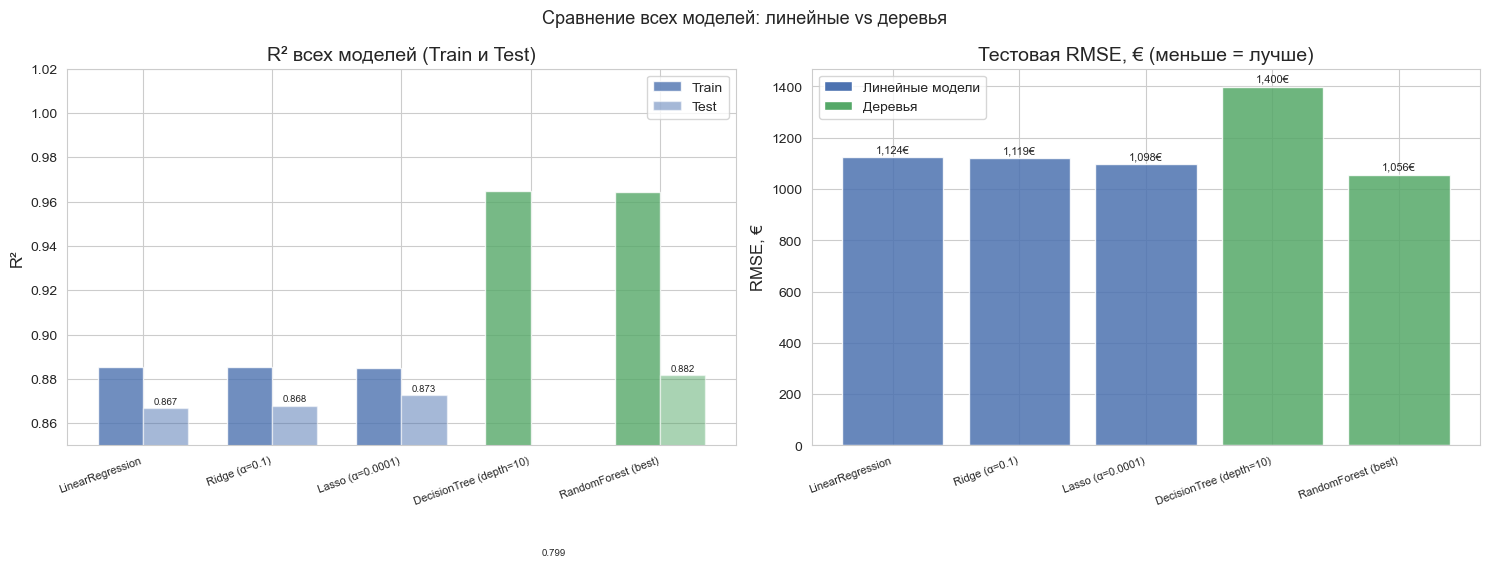

In [31]:
# Визуализация сравнения всех моделей
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

names  = [r['Модель'] for r in all_results]
test_r2   = [r['Test_R2']      for r in all_results]
test_rmse = [r['Test_RMSE_EUR'] for r in all_results]
train_r2  = [r['Train_R2']     for r in all_results]

x = np.arange(len(names))
w = 0.35
colors_map = ['#4C72B0','#4C72B0','#4C72B0','#55A868','#55A868']  # синий=линейные, зелёный=деревья

# R²
bars1 = axes[0].bar(x - w/2, train_r2, w, label='Train', alpha=0.8,
                    color=['#4C72B0']*3 + ['#55A868']*2)
bars2 = axes[0].bar(x + w/2, test_r2,  w, label='Test',  alpha=0.5,
                    color=['#4C72B0']*3 + ['#55A868']*2)
axes[0].set_xticks(x)
axes[0].set_xticklabels(names, rotation=20, ha='right', fontsize=8)
axes[0].set_ylim(0.85, 1.02)
axes[0].set_title('R² всех моделей (Train и Test)')
axes[0].set_ylabel('R²')
axes[0].legend()
for b in list(bars2):
    axes[0].text(b.get_x() + b.get_width()/2, b.get_height() + 0.001,
                 f'{b.get_height():.3f}', ha='center', va='bottom', fontsize=7)

# RMSE в евро
bar_colors = ['#4C72B0']*3 + ['#55A868']*2
brs = axes[1].bar(x, test_rmse, color=bar_colors, alpha=0.85)
axes[1].set_xticks(x)
axes[1].set_xticklabels(names, rotation=20, ha='right', fontsize=8)
axes[1].set_title('Тестовая RMSE, € (меньше = лучше)')
axes[1].set_ylabel('RMSE, €')
for b in brs:
    axes[1].text(b.get_x() + b.get_width()/2, b.get_height() + 10,
                 f'{b.get_height():,.0f}€', ha='center', va='bottom', fontsize=8)

# Легенда типов моделей
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#4C72B0', label='Линейные модели'),
                   Patch(facecolor='#55A868', label='Деревья')]
axes[1].legend(handles=legend_elements)

plt.suptitle('Сравнение всех моделей: линейные vs деревья', fontsize=13)
plt.tight_layout()
plt.savefig('all_models_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

### 9.5 Важность признаков (Feature Importance) — Random Forest

Топ-15 самых важных признаков (Random Forest):
           Признак  Важность
Age_KM_interaction  0.548042
         Age_08_04  0.151523
       Age_squared  0.145225
            Weight  0.025878
                KM  0.025214
            log_KM  0.024952
     Quarterly_Tax  0.009263
   Power_to_Weight  0.008377
     Options_Count  0.007483
                HP  0.006156
             Airco  0.003788
   BOVAG_Guarantee  0.003564
     Mfr_Guarantee  0.003421
   Automatic_airco  0.003257
      Central_Lock  0.002268


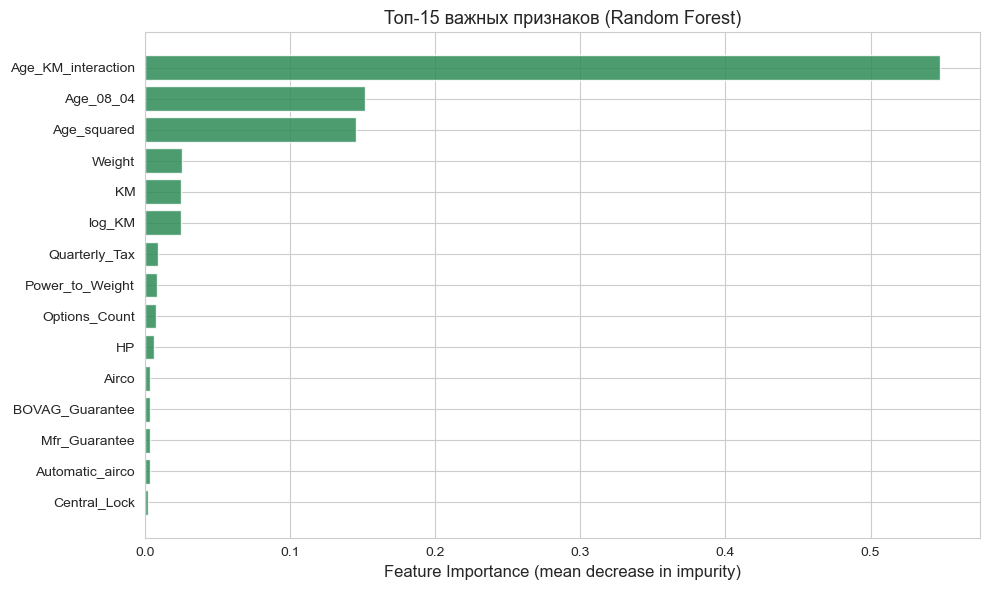

In [32]:
rf_model = best_rf_pipe.named_steps['model']

# Получаем имена признаков после препроцессора
ohe_names = list(
    best_rf_pipe.named_steps['preprocessor']
    .named_transformers_['cat']
    .get_feature_names_out(cat_features)
)
rf_feature_names = num_features + ohe_names

importances = rf_model.feature_importances_
imp_df = pd.DataFrame({
    'Признак': rf_feature_names,
    'Важность': importances
}).sort_values('Важность', ascending=False)

print("Топ-15 самых важных признаков (Random Forest):")
print(imp_df.head(15).to_string(index=False))

# График
top15_rf = imp_df.head(15)
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top15_rf['Признак'][::-1], top15_rf['Важность'][::-1],
        color='seagreen', alpha=0.85)
ax.set_title('Топ-15 важных признаков (Random Forest)', fontsize=13)
ax.set_xlabel('Feature Importance (mean decrease in impurity)')
plt.tight_layout()
plt.savefig('rf_feature_importance.png', dpi=120, bbox_inches='tight')
plt.show()

## 10. Ответы на вопросы ДЗ #5

---

### Предобработка для случайного леса

**Отличалась ли она от предобработки для линейной модели?**  
Да. Для линейной регрессии необходим `StandardScaler` -иначе признаки с разными диапазонами дают несравнимые коэффициенты, а регуляризация (Ridge/Lasso) работает некорректно. Деревья решений разбивают пространство по порогам - абсолютные значения признаков им безразличны, масштабирование убрано. One-Hot Encoding оставлен для удобства, но RF справился бы и с ordinal-кодированием.

---

### Разделение выборки

**Как разделили:** то же разбиение 80/20, что и для линейных моделей - честное сравнение требует одинаковых условий.

**На сколько частей делить при кросс-валидации?** 5 фолдов - стандарт для датасетов от ~500 объектов. Каждый фолд содержит достаточно данных для стабильной оценки.

**Можно ли без кросс-валидации?** Да - делить на 3 части: train / validation / test. Но кросс-валидация эффективнее использует данные и даёт более стабильную оценку.

---

### Сравнение скорости

| Модель | Время (1 fit) |
|--------|--------------|
| DecisionTree (depth=10) | ~14 мс |
| RandomForest (200 деревьев) | ~1180 мс |

RF в ~85x медленнее одного дерева — строит 200 независимых деревьев. Ускорить можно через `n_jobs=-1` (параллелизм по ядрам) или уменьшением `n_estimators`. При `n_estimators=1` RF = одно дерево, скорость одинакова.

---

### Сравнение качества

| Модель | Train R² | Test R² | RMSE | Переобучение |
|--------|----------|---------|------|-------------|
| LinearRegression | 0.885 | 0.867 | 1124€ | ✅ нет |
| Ridge | 0.885 | 0.868 | 1119€ | ✅ нет |
| Lasso | 0.885 | 0.873 | 1098€ | ✅ нет |
| DecisionTree (depth=10) | 0.965 | 0.799 | 1400€ | ❌ переобучение |
| **RandomForest (best)** | **0.964** | **0.882** | **1056€** | ⚠️ умеренное |

**Одно дерево** сильно переобучается (gap Train−Test = 0.166): точно запоминает тренировочные данные, но плохо обобщает. Test R²=0.80 — хуже линейных моделей.

**RandomForest** — лучший Test R² (0.882) и наименьшая RMSE (1056€). Усреднение 200 деревьев снижает дисперсию и сглаживает переобучение (gap=0.083 — умеренный).

**Что важно:** линейные модели в данном случае держатся очень хорошо (R²≈0.87) — этому помогает качественная feature engineering (Age_squared, log_KM, Age_KM_interaction). RF выигрывает, но не разгромно, что говорит о хорошей предобработке данных для линейных моделей.

**Feature Importance RF:** топ-признаки — `Age_KM_interaction` (54.8%), `Age_08_04` (15.2%), `Age_squared` (14.5%). Инженерные признаки, созданные вручную, оказались важнейшими — это подтверждает правильность feature engineering.

---

### Метрики

Использованы **R²**, **RMSE** (в log-пространстве и в €). RMSE штрафует крупные ошибки сильнее — важно в задаче оценки стоимости. R² даёт нормированную оценку относительно тривиального предсказания средним (Dummy). Метрики считались на тестовой выборке, не участвовавшей в обучении.